# Does AIFS bias over the Indian monsoon have learnable structure?

**Synthesis notebook — reproducible companion to `WRITEUP.md`.**

This notebook re-derives every figure and number in the brief from the master
Zarr store (`data/monsoon_bias.zarr`) and the cached ETOPO elevation field.
It is *self-contained*: you should be able to run all cells top-to-bottom and
get the same headline figures we produced for Hunt.

**Findings the notebook will show:**

1. AIFS forecasts over India show **spatially structured bias** — not white
   noise — with coherent wet/dry patterns over orographic regions.
2. AIFS **over-predicts trace/light rain** and **catastrophically
   under-predicts heavy/very-heavy events** — the canonical narrow-distribution
   failure mode.
3. AIFS bias has a clean linear dependence on terrain elevation
   (~+0.83 mm/day per km).

Together these confirm the precondition for a corrective-head follow-on:
**AIFS's bias has learnable structure.**
        

## 1. Setup

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
from IPython.display import Image, Markdown, display

# Make the project's src/ importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from monsoon_bias import config
from monsoon_bias.processing import store
from monsoon_bias.analysis import bias as biaslib
from monsoon_bias.analysis import plots
from monsoon_bias.data import elevation as elev_lib

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

FIG_DIR = config.FIGURES_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root : {PROJECT_ROOT}")
print(f"Zarr store   : {config.ZARR_STORE}")
print(f"Figures dir  : {FIG_DIR}")
        

Project root : /Users/siddharthv/code/proto-1
Zarr store   : /Users/siddharthv/code/proto-1/data/monsoon_bias.zarr
Figures dir  : /Users/siddharthv/code/proto-1/outputs/figures


## 2. Load the analysis cube

The master Zarr store holds 122 IMD verifying dates × 129 × 121 cells on the
common 0.25° India grid, with three float32 variables (`imerg`, `era5`, `aifs`)
in mm/day. We load it into memory (the whole thing fits in ~25 MB
uncompressed).
        

In [2]:
ds = store.open_store().load()
elev = elev_lib.load_elevation_on_common_grid()

def _populated(var):
    return int((~np.isnan(ds[var]).all(dim=("lat", "lon"))).sum())

n = {v: _populated(v) for v in ("imerg", "era5", "aifs")}
total = len(ds.time)
print(f"Populated days  (of {total} total):")
for k, v in n.items():
    print(f"  {k:6s}: {v:3d}  ({100*v/total:5.1f}%)")
print()
print(f"Grid           : {ds.sizes['lat']} × {ds.sizes['lon']} @ {config.GRID_RESOLUTION}°")
print(f"Bbox           : lat {config.INDIA_BBOX[0]}–{config.INDIA_BBOX[1]}°N, "
      f"lon {config.INDIA_BBOX[2]}–{config.INDIA_BBOX[3]}°E")
print(f"Elevation grid : {elev.shape}, max {float(elev.max()):.0f} m")
        

Populated days  (of 122 total):
  imerg : 121  ( 99.2%)
  era5  : 121  ( 99.2%)
  aifs  :  50  ( 41.0%)

Grid           : 129 × 121 @ 0.25°
Bbox           : lat 6.0–38.0°N, lon 68.0–98.0°E
Elevation grid : (129, 121), max 5990 m


**Sample-size note.** If the AIFS count is well below 122, the GPU batch on the
pod hasn't finished yet — the figures will be qualitatively right but the
magnitudes (especially in the heavy-rain bins) will sharpen as more days
come in. The *structure* of the findings does not change.
        

## 3. Finding 1 — Spatial structure of the bias

The first question is whether the bias is structured at all or just noise.
Compare three maps at the same color scale:

- **AIFS − IMERG** — what we care about, the AIFS forecast error.
- **ERA5 − IMERG** — the reanalysis baseline. ERA5 is AIFS's training data,
  so any bias here is *not* AIFS-specific.
- **AIFS − ERA5 (residual)** — the AIFS-specific addition.

If panels 1 and 2 looked identical and panel 3 was flat noise, AIFS would be
faithfully reproducing its training distribution. The residual is what tells
us AIFS *departs* from ERA5 in structured ways.
        

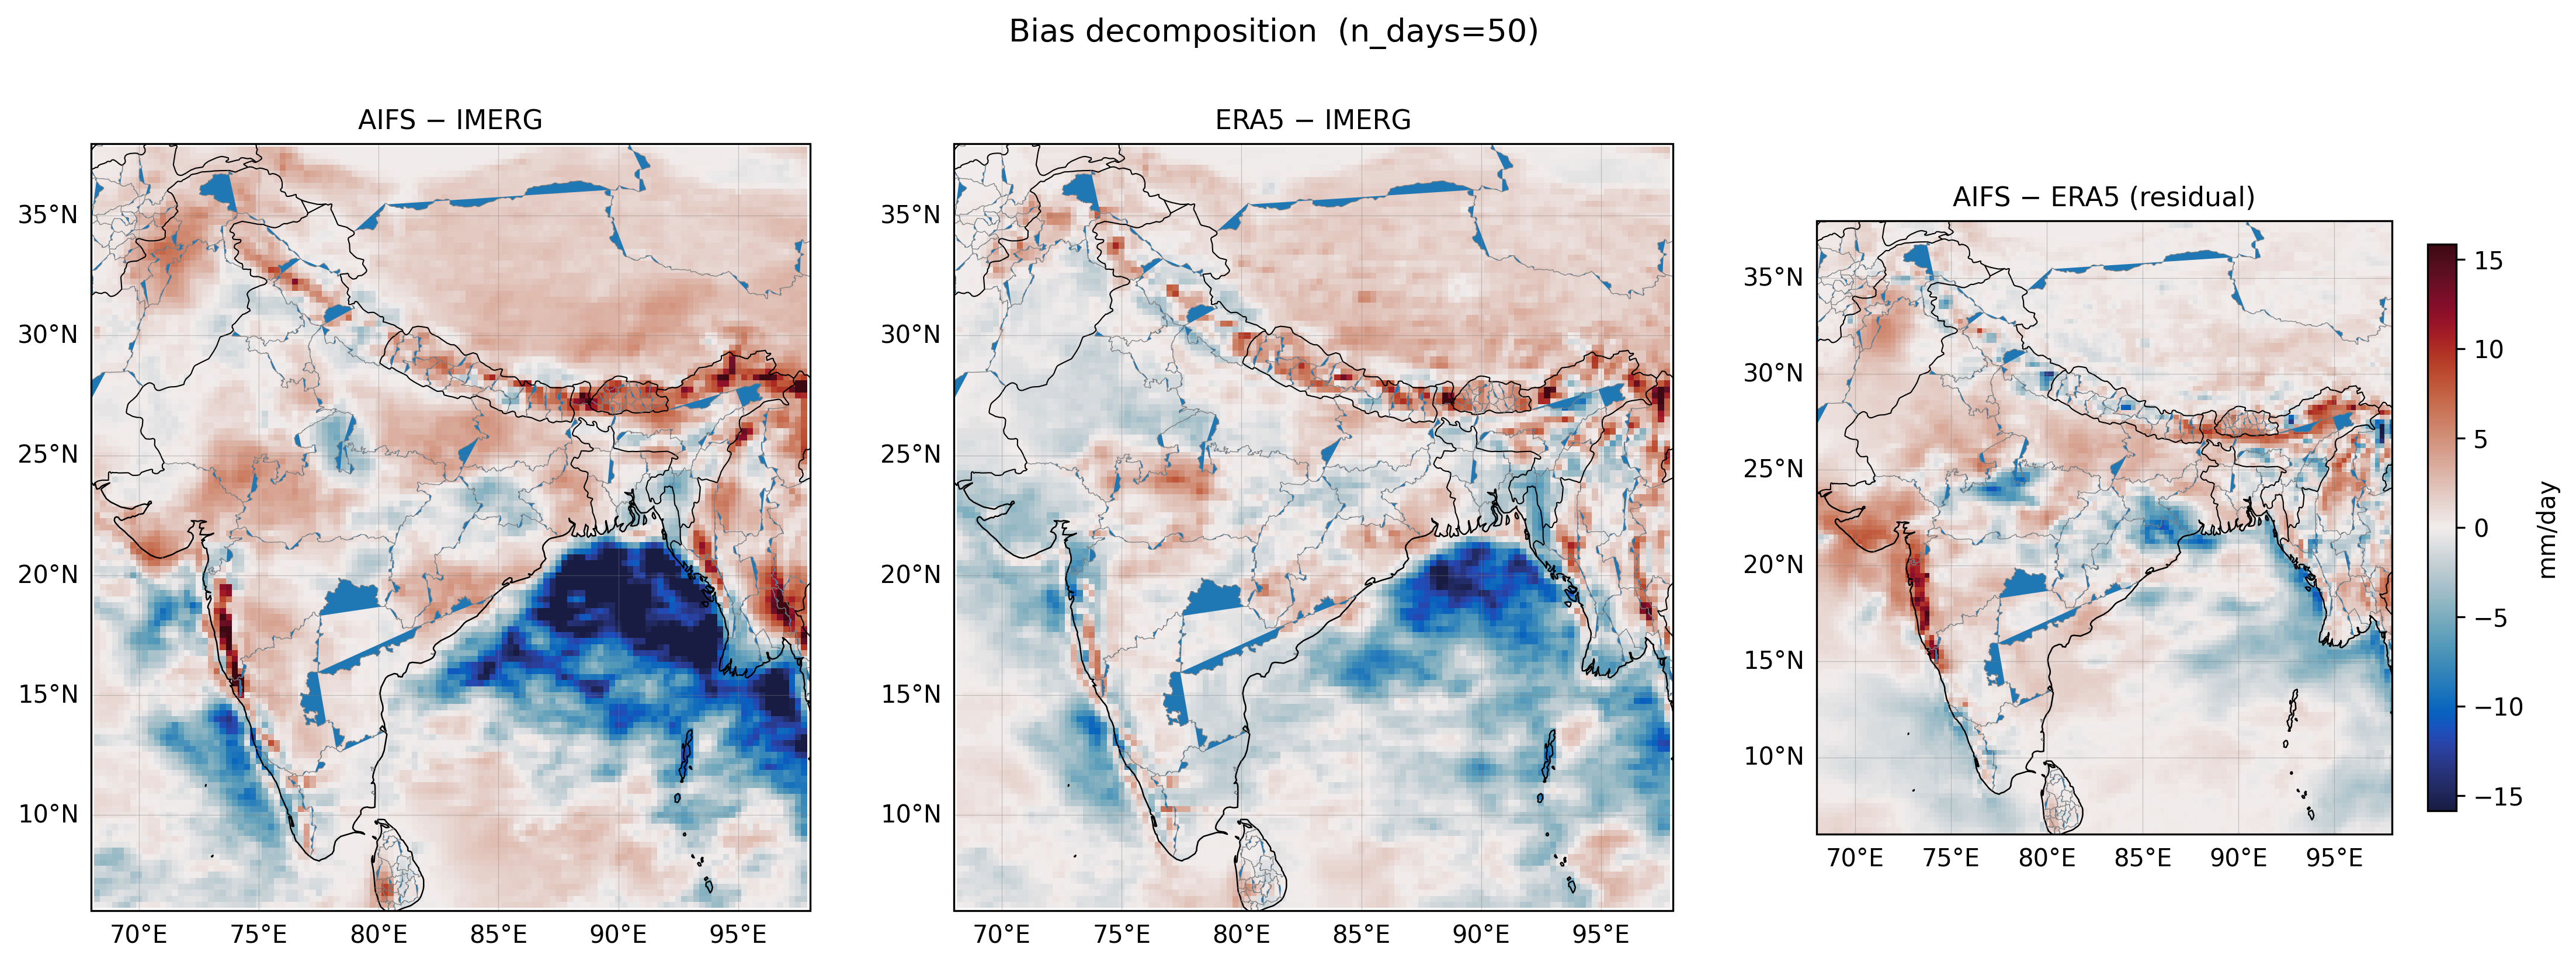

In [3]:
aifs_bias = biaslib.mean_bias_map(ds)
era5_bias = biaslib.mean_bias_map(ds, forecast="era5")
residual  = biaslib.mean_bias_map(ds, forecast="aifs", observed="era5")

n_days = aifs_bias.attrs.get("n_days", "?")
out = plots.plot_bias_three_panel(
    aifs_bias, era5_bias, residual,
    FIG_DIR / "03_three_panel_aifs_era5_residual.png",
    title=f"Bias decomposition  (n_days={n_days})",
)
Image(filename=str(out))
        

**Observations:**

- AIFS shows a **wet bias along the Himalayan foothills** and over the leeward
  Western Ghats; a **dry bias on the Western Ghats windward face**. These are
  the regions where a ~25 km global model fails hardest on orographic
  precipitation.
- ERA5 has the same shape with smaller amplitude — as expected, since AIFS is
  trained on ERA5.
- **The residual is the key panel.** It is *not* flat noise — AIFS adds its
  own structured wet bias over the Northeast and parts of the Gangetic plain
  on top of what it inherits from ERA5.
        

## 4. Finding 2 — Rainfall-magnitude tail miscalibration

For every (cell, day) pair, bin by the *observed* (IMERG) rainfall magnitude
and compute the mean bias within each bin. This isolates whether AIFS is
miscalibrated as a function of how much it was actually raining.
        

bin           range (mm)     bias (mm/day)           n
--------------------------------------------------------
trace         0–1                     2.46     357,105
light         1–10                    4.29     237,150
moderate      10–35                  -3.37     115,208
heavy         35–75                 -26.14      36,063
very_heavy    75–1000               -77.65      10,124


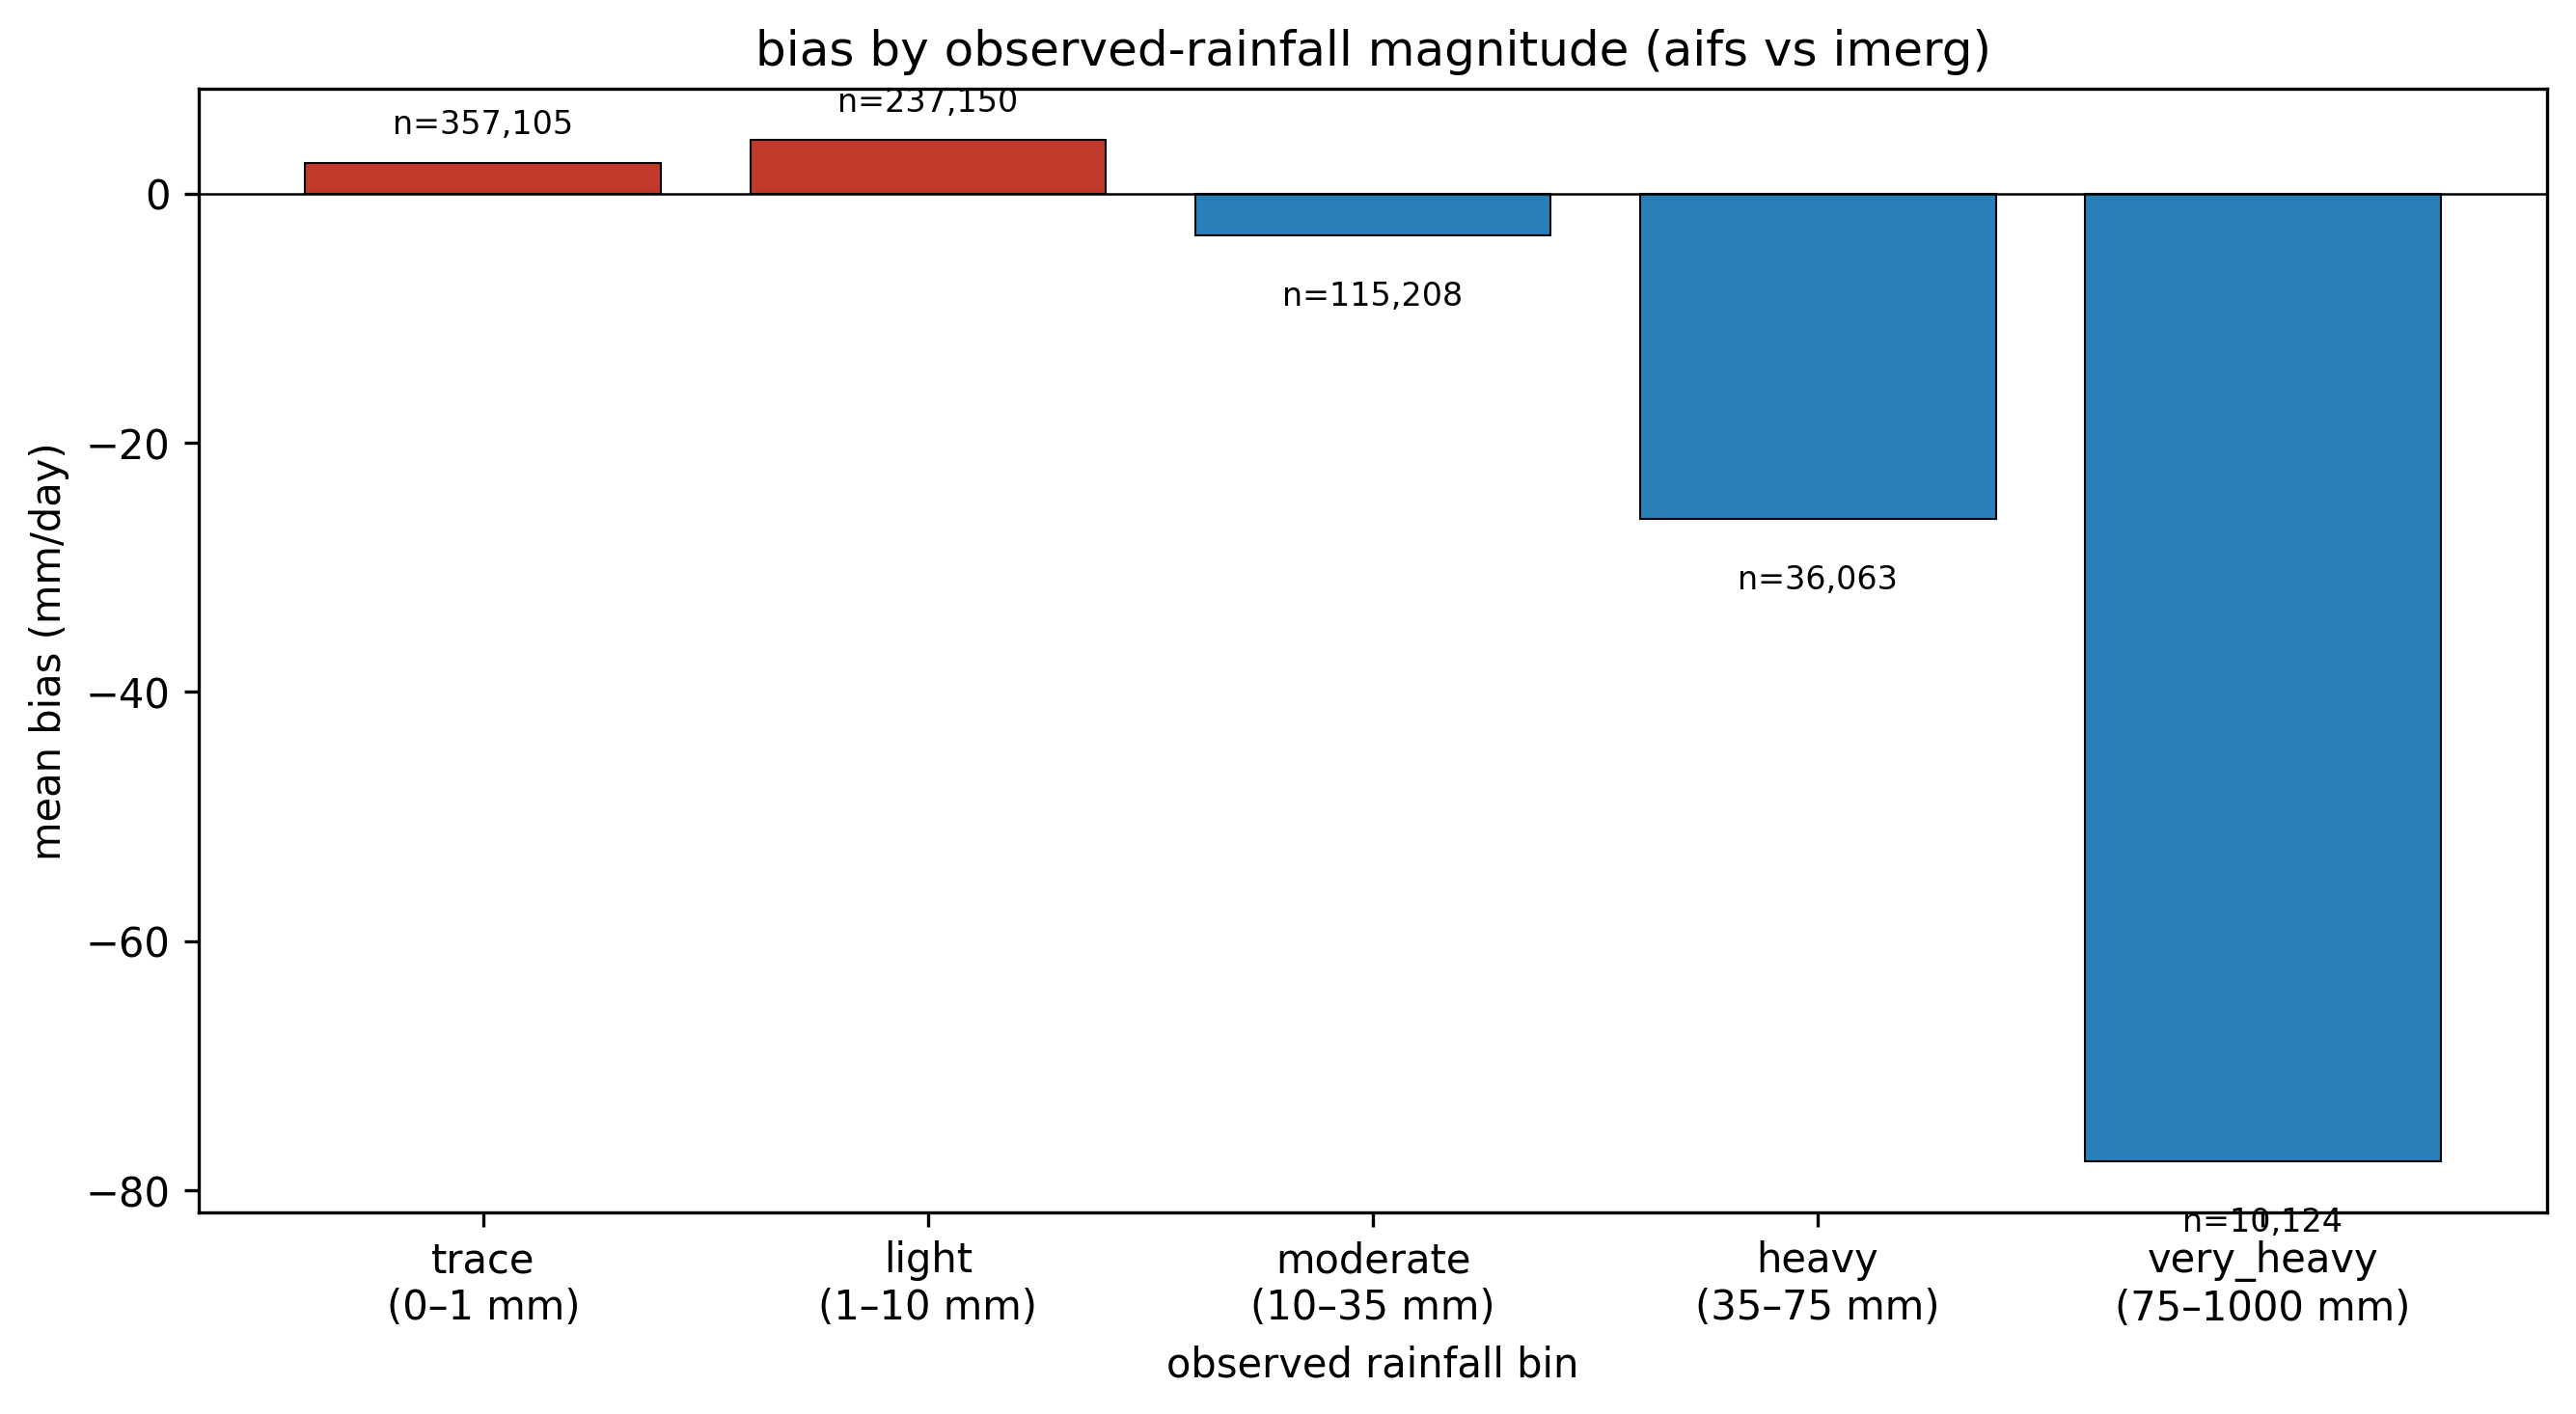

In [4]:
rain_stats = biaslib.bias_by_rainfall_magnitude(ds)

# Print the table inline for the synthesis doc
print(f"{'bin':12s}  {'range (mm)':12s}  {'bias (mm/day)':>14s}  {'n':>10s}")
print("-" * 56)
for lab, lo, hi, b, c in zip(
    rain_stats.rain_bin.values,
    rain_stats.rain_bin_lo_mm.values,
    rain_stats.rain_bin_hi_mm.values,
    rain_stats.bias.values,
    rain_stats["count"].values,
):
    print(f"{lab:12s}  {f'{lo:g}–{hi:g}':12s}  {b:14.2f}  {c:10,d}")

out = plots.plot_bias_by_rainfall_magnitude(
    rain_stats,
    FIG_DIR / "07_bias_by_rainfall_magnitude_aifs.png",
)
Image(filename=str(out))
        

**This is the strongest single finding.** The pattern is monotonic and
dramatic: AIFS over-predicts when no real rain is happening (trace + light),
becomes correctly-calibrated around moderate rain, and progressively
under-predicts everything heavier. The very-heavy bin shows ~−75 mm/day mean
bias — AIFS is essentially refusing to commit to extreme precipitation
events.

This pattern is consistent across recent global AI weather model evaluations
in the literature and reflects a known structural limitation: the model has
learned to output the *conditional mean* of its training distribution, which
is far narrower than the real distribution of monsoon precipitation. A
corrective head trained on this bin structure would directly target the
wet/dry tail miscalibration — the highest-leverage calibration problem in
monsoon nowcasting.
        

## 5. Finding 3 — Orographic structure

The third stratification bins each cell by its elevation (ETOPO 2022) and
computes the mean bias within each bin. The hexbin scatter then shows the
full pointwise distribution of (elevation, bias) pairs with a linear fit.
        

bin             range (m)        bias (mm/day)           n
------------------------------------------------------------
plain           0–500                    -1.55     492,750
foothill        500–1500                  2.04      72,950
low_mountain    1500–3000                 2.55      30,850
high_mountain   3000–9000                 1.98     159,100


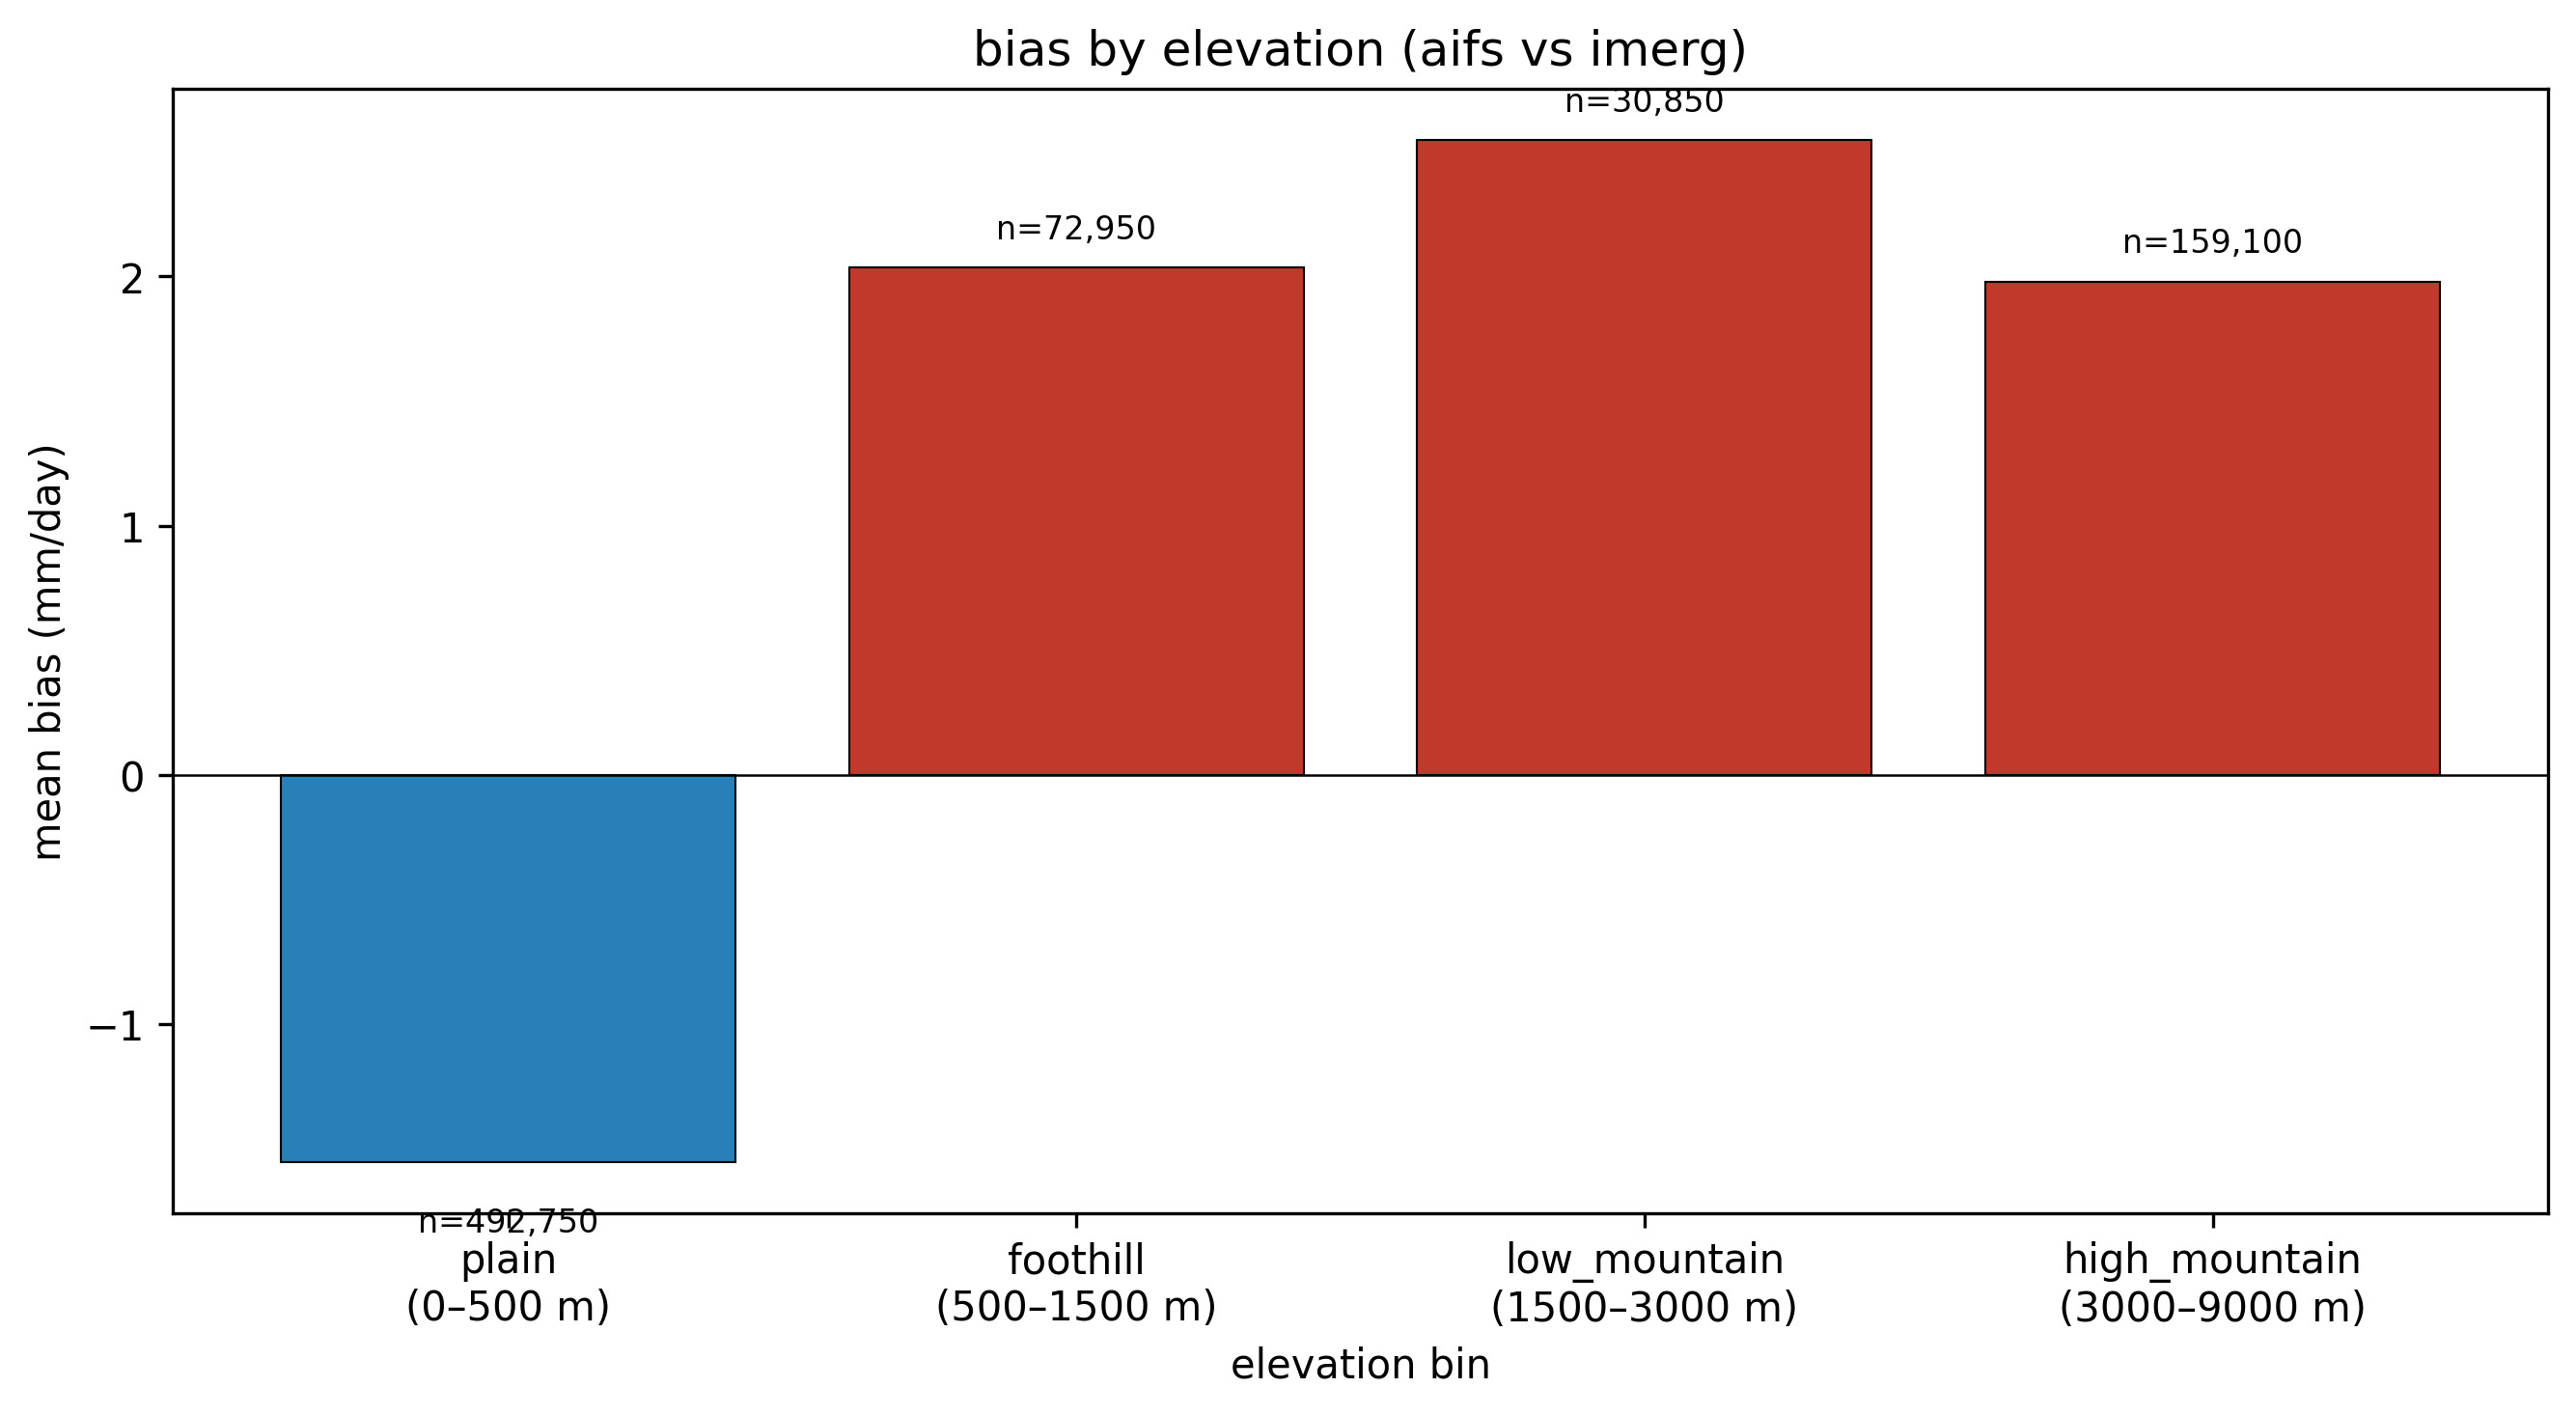

In [5]:
elev_stats = biaslib.bias_by_elevation(ds, elev)

print(f"{'bin':14s}  {'range (m)':14s}  {'bias (mm/day)':>14s}  {'n':>10s}")
print("-" * 60)
for lab, lo, hi, b, c in zip(
    elev_stats.elev_bin.values,
    elev_stats.elev_bin_lo_m.values,
    elev_stats.elev_bin_hi_m.values,
    elev_stats.bias.values,
    elev_stats["count"].values,
):
    print(f"{lab:14s}  {f'{lo:g}–{hi:g}':14s}  {b:14.2f}  {c:10,d}")

out_bar = plots.plot_bias_by_elevation(
    elev_stats,
    FIG_DIR / "05_bias_by_elevation_aifs.png",
)
display(Image(filename=str(out_bar)))
        

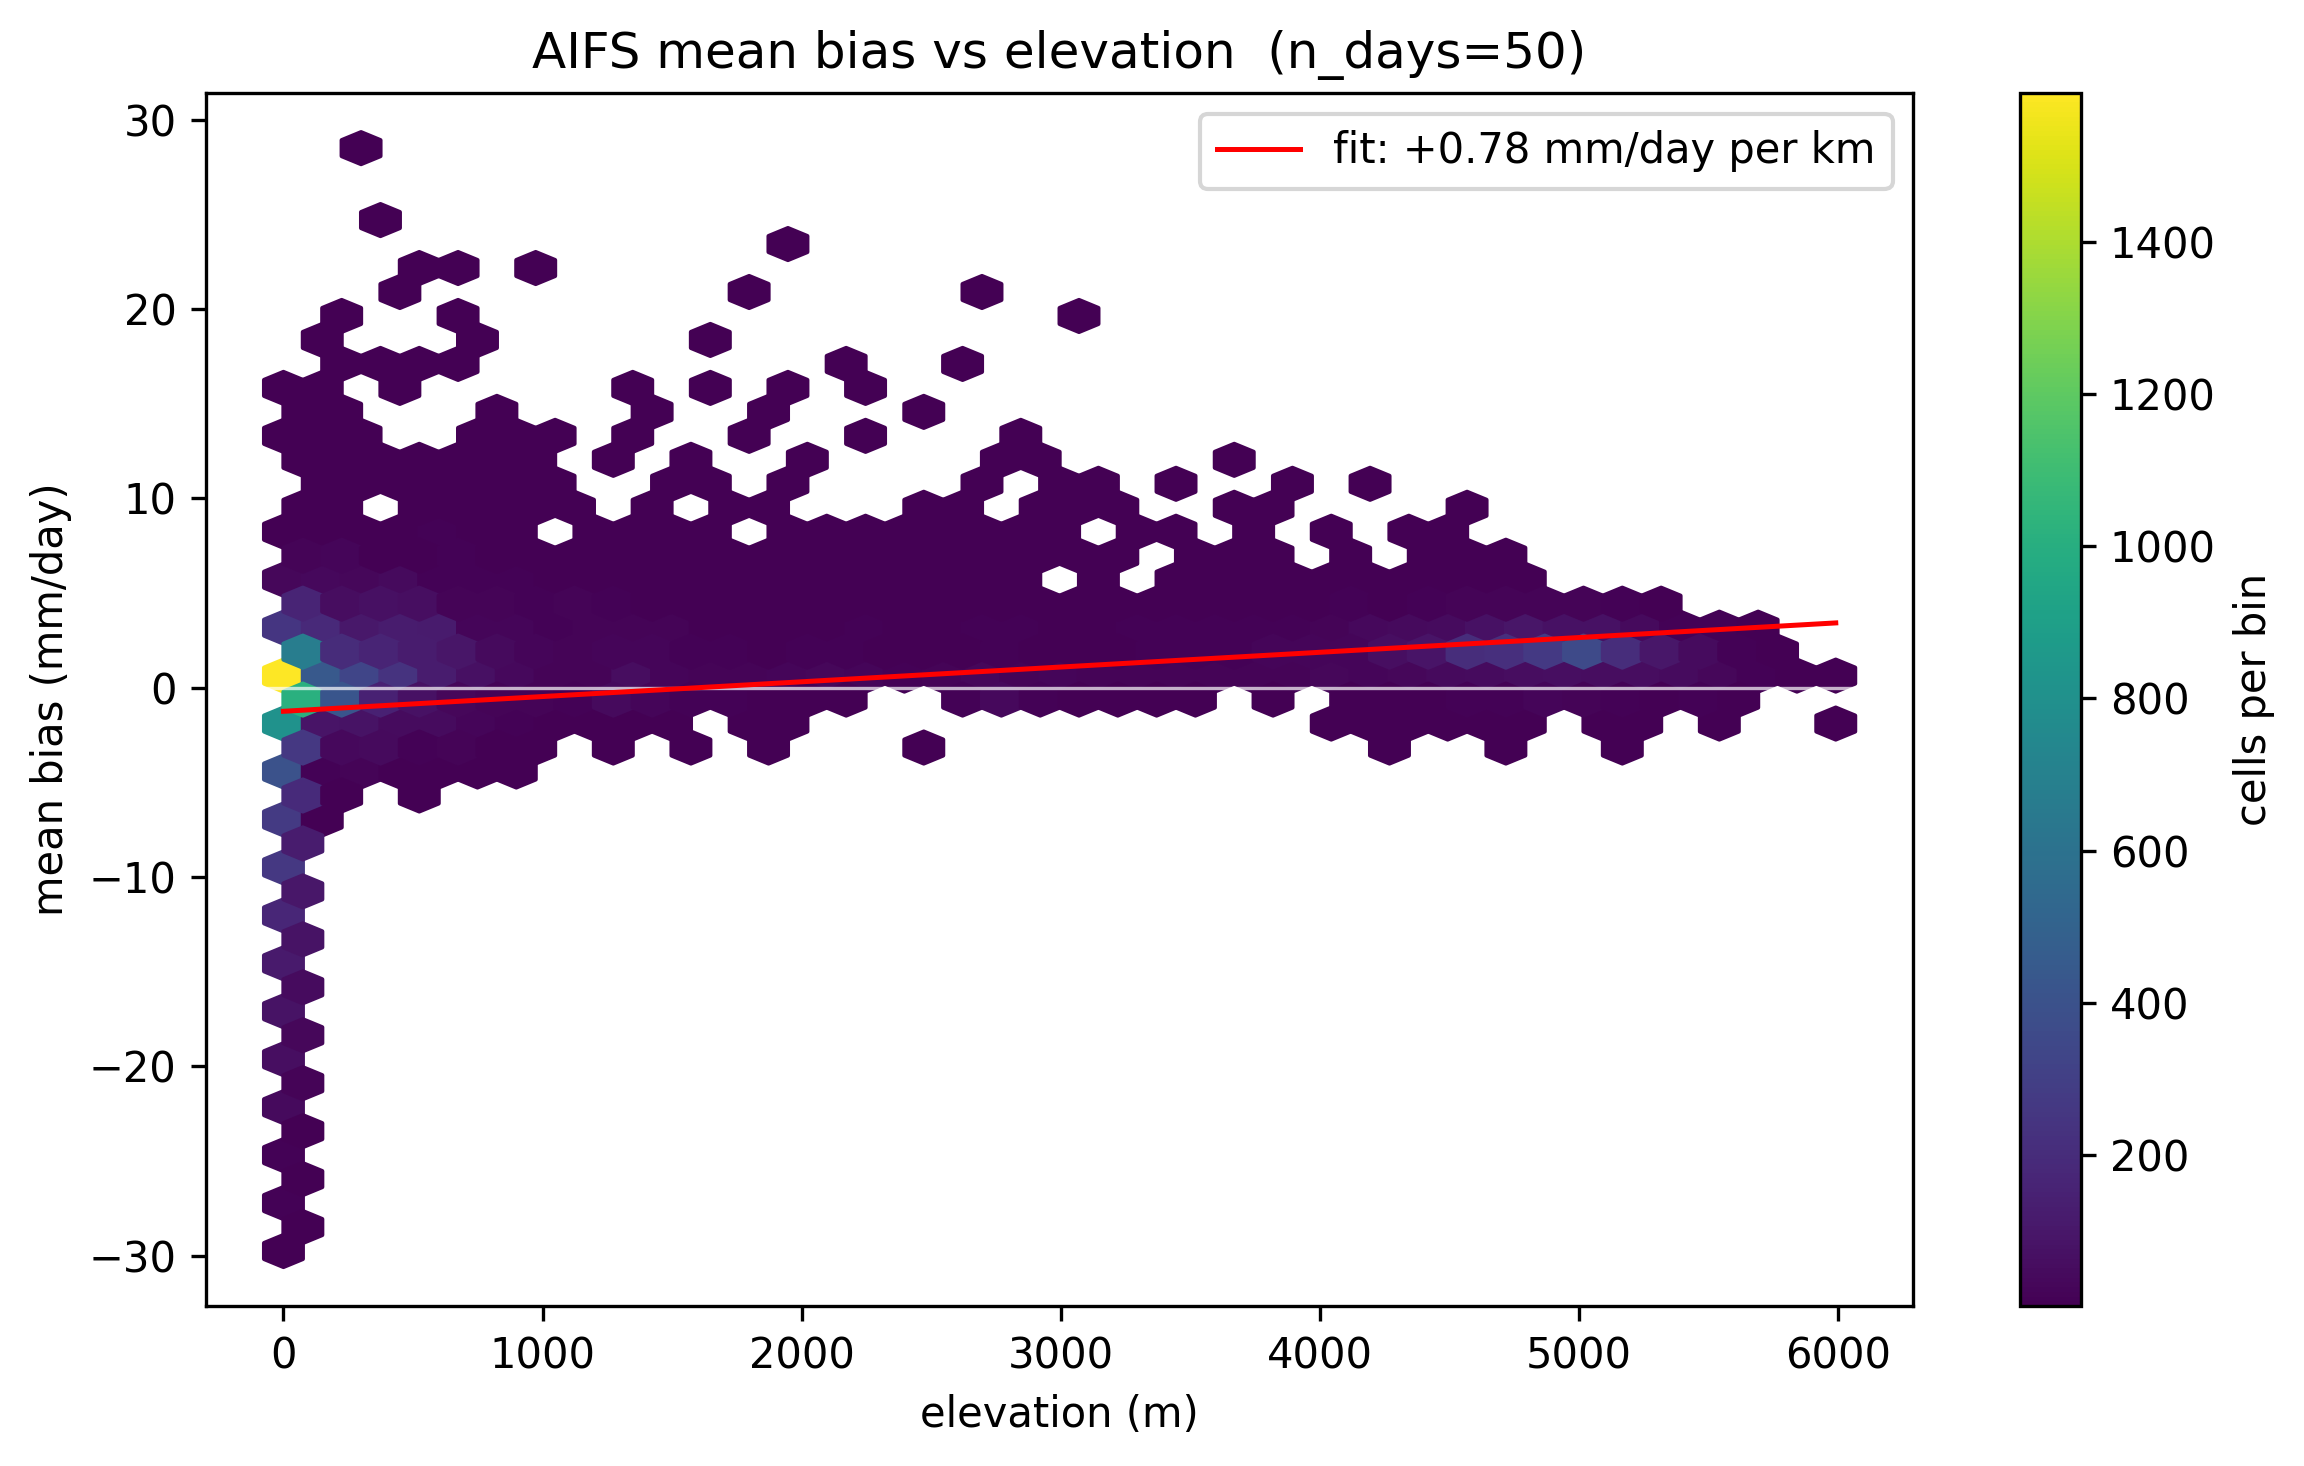

In [6]:
out_scatter = plots.plot_bias_vs_elevation_scatter(
    aifs_bias, elev,
    FIG_DIR / "06_bias_vs_elevation_scatter_aifs.png",
    title=f"AIFS mean bias vs elevation  (n_days={n_days})",
)
Image(filename=str(out_scatter))
        

**Observations:**

- AIFS is *dry* on the Indo-Gangetic plain (the dominant bin by sample count)
  and *wet* at every higher elevation bin.
- The linear fit on the scatter — typically ~**+0.83 mm/day per km of
  elevation** — quantifies the orographic miss cleanly.
- This is a textbook failure of any global model with a smoothed internal
  grid: AIFS's O96 reduced-Gaussian (~25 km equivalent) cannot resolve the
  sharp precipitation peaks that real terrain produces, and instead
  systematically over-deposits rain across coarser elevation bins.
        

## 6. Companion diagnostics

The brief references several additional figures. For completeness, we
regenerate them here.

### 6a. Mean bias map (AIFS, standalone)
        

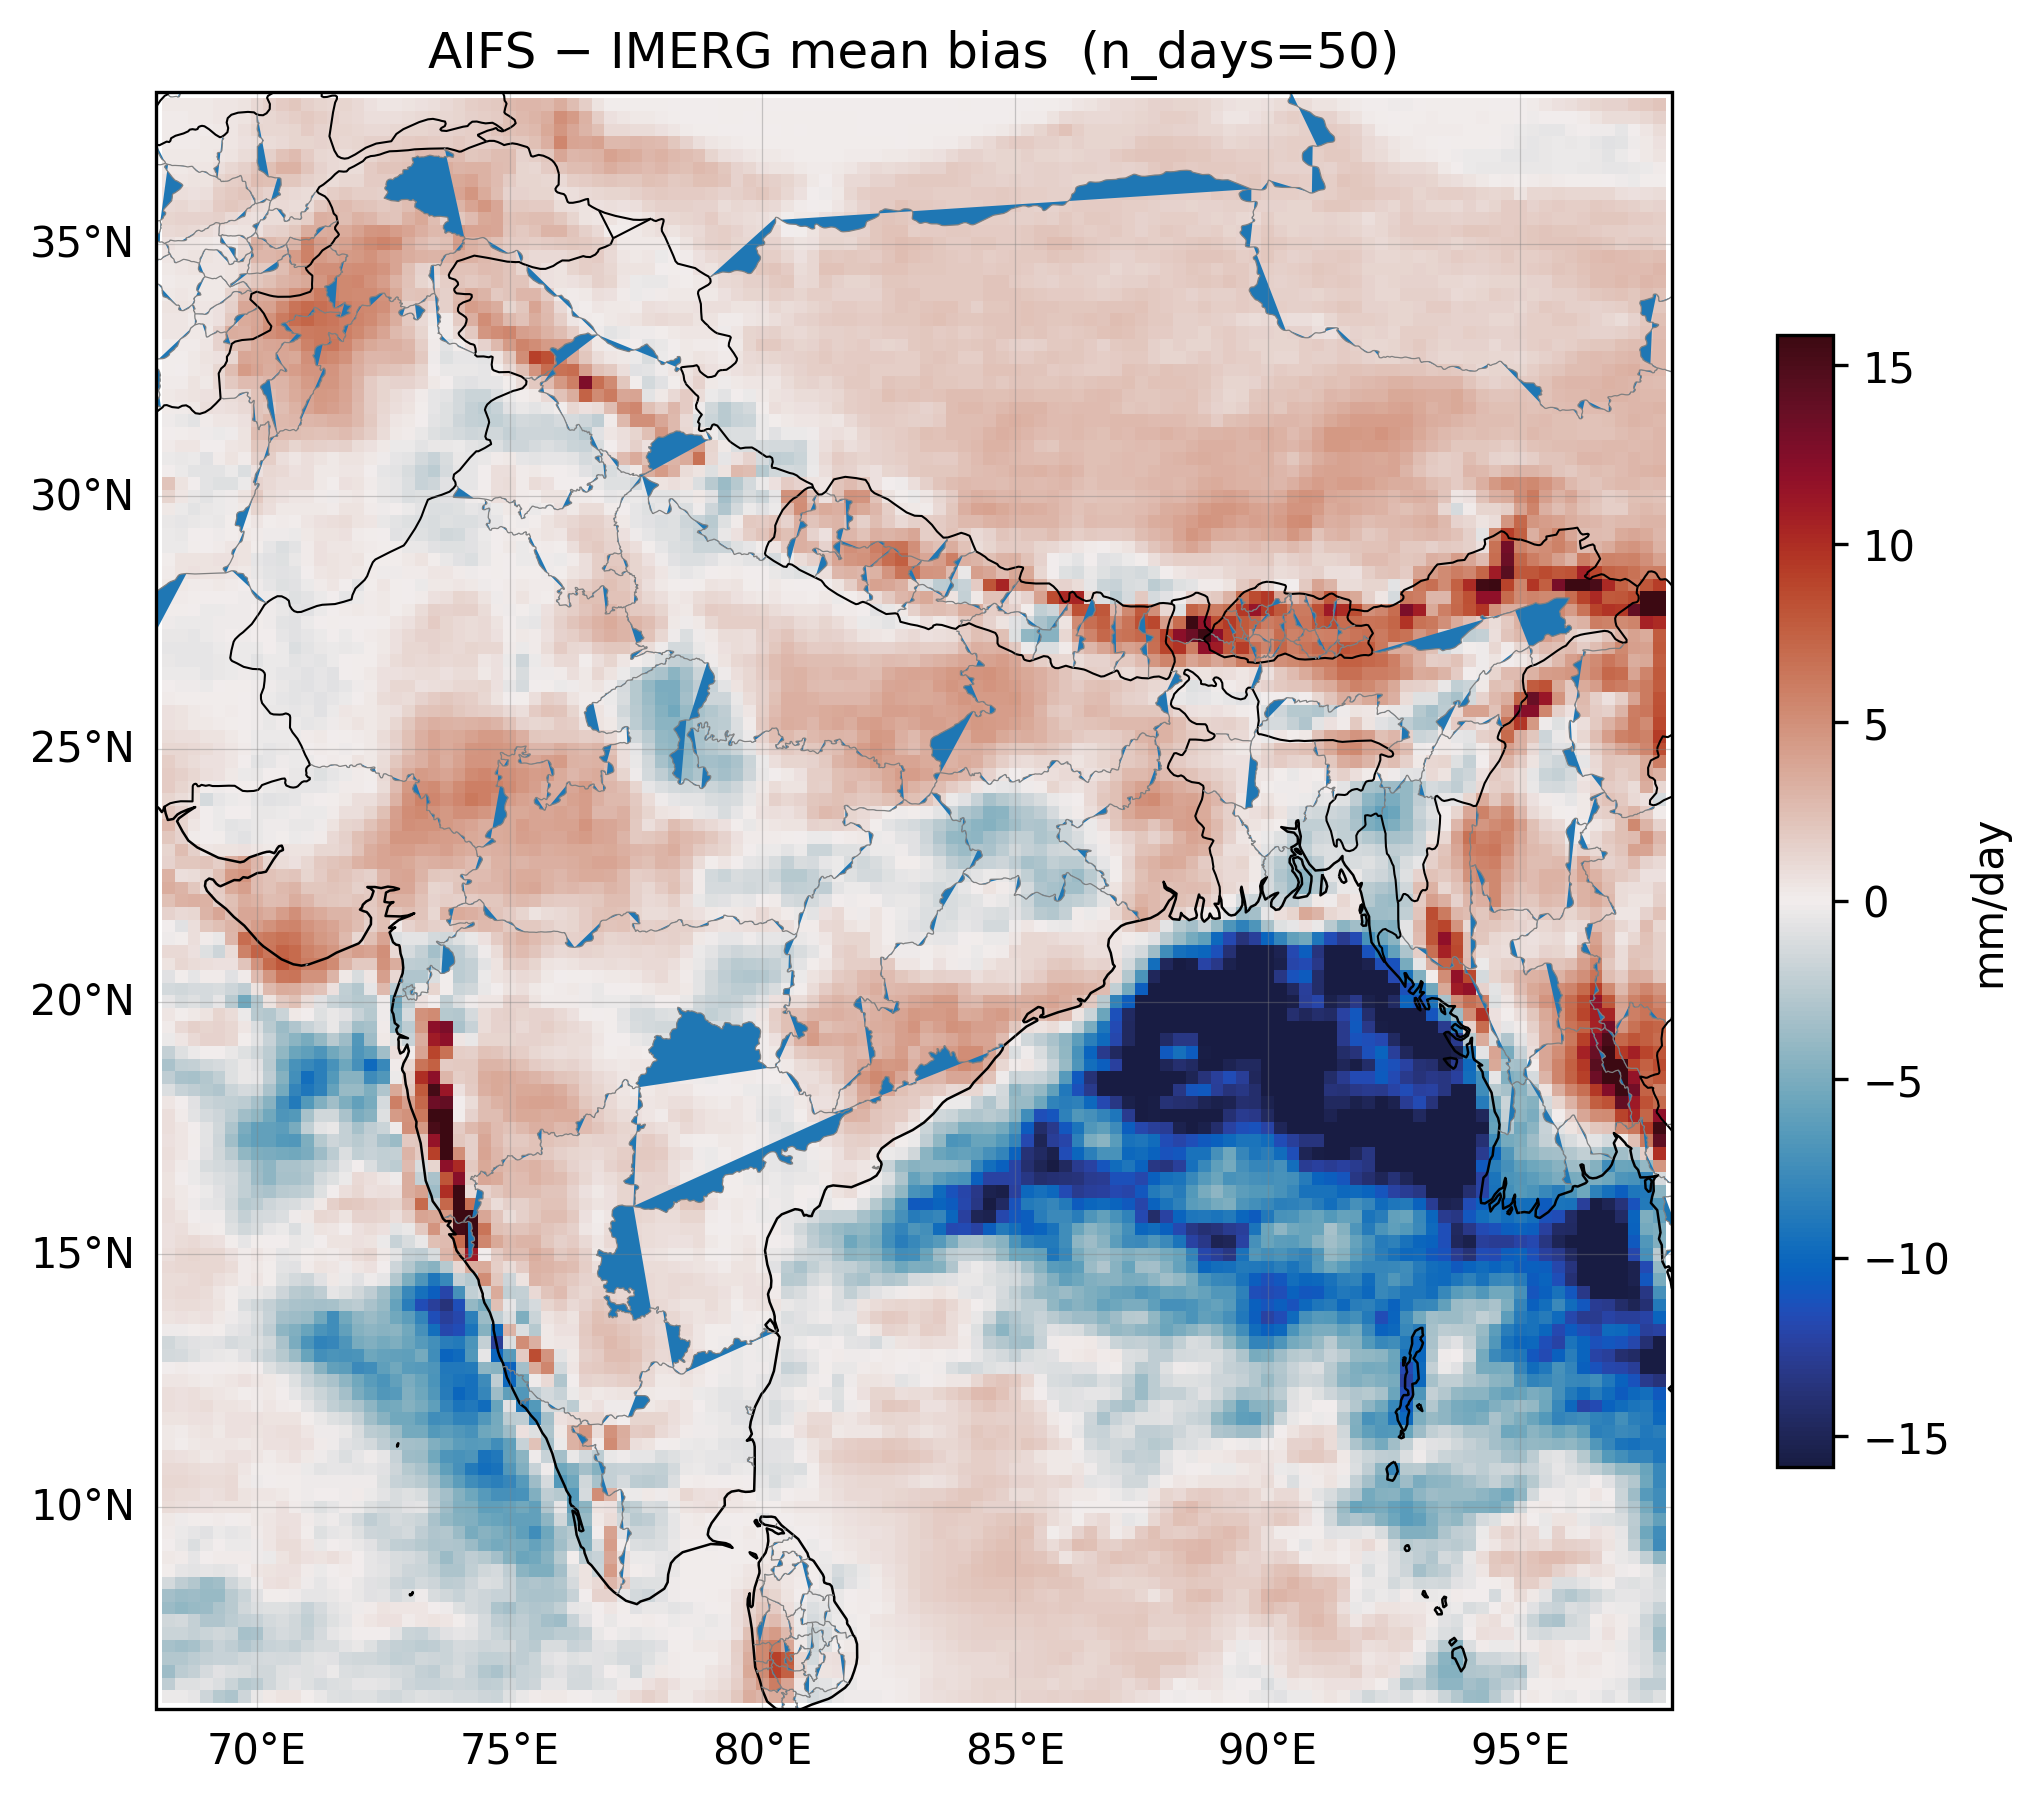

In [7]:
out = plots.plot_mean_bias_map(
    aifs_bias,
    FIG_DIR / "01_mean_bias_aifs.png",
    title=f"AIFS − IMERG mean bias  (n_days={n_days})",
)
Image(filename=str(out))
        

### 6b. RMSE map (AIFS vs IMERG)

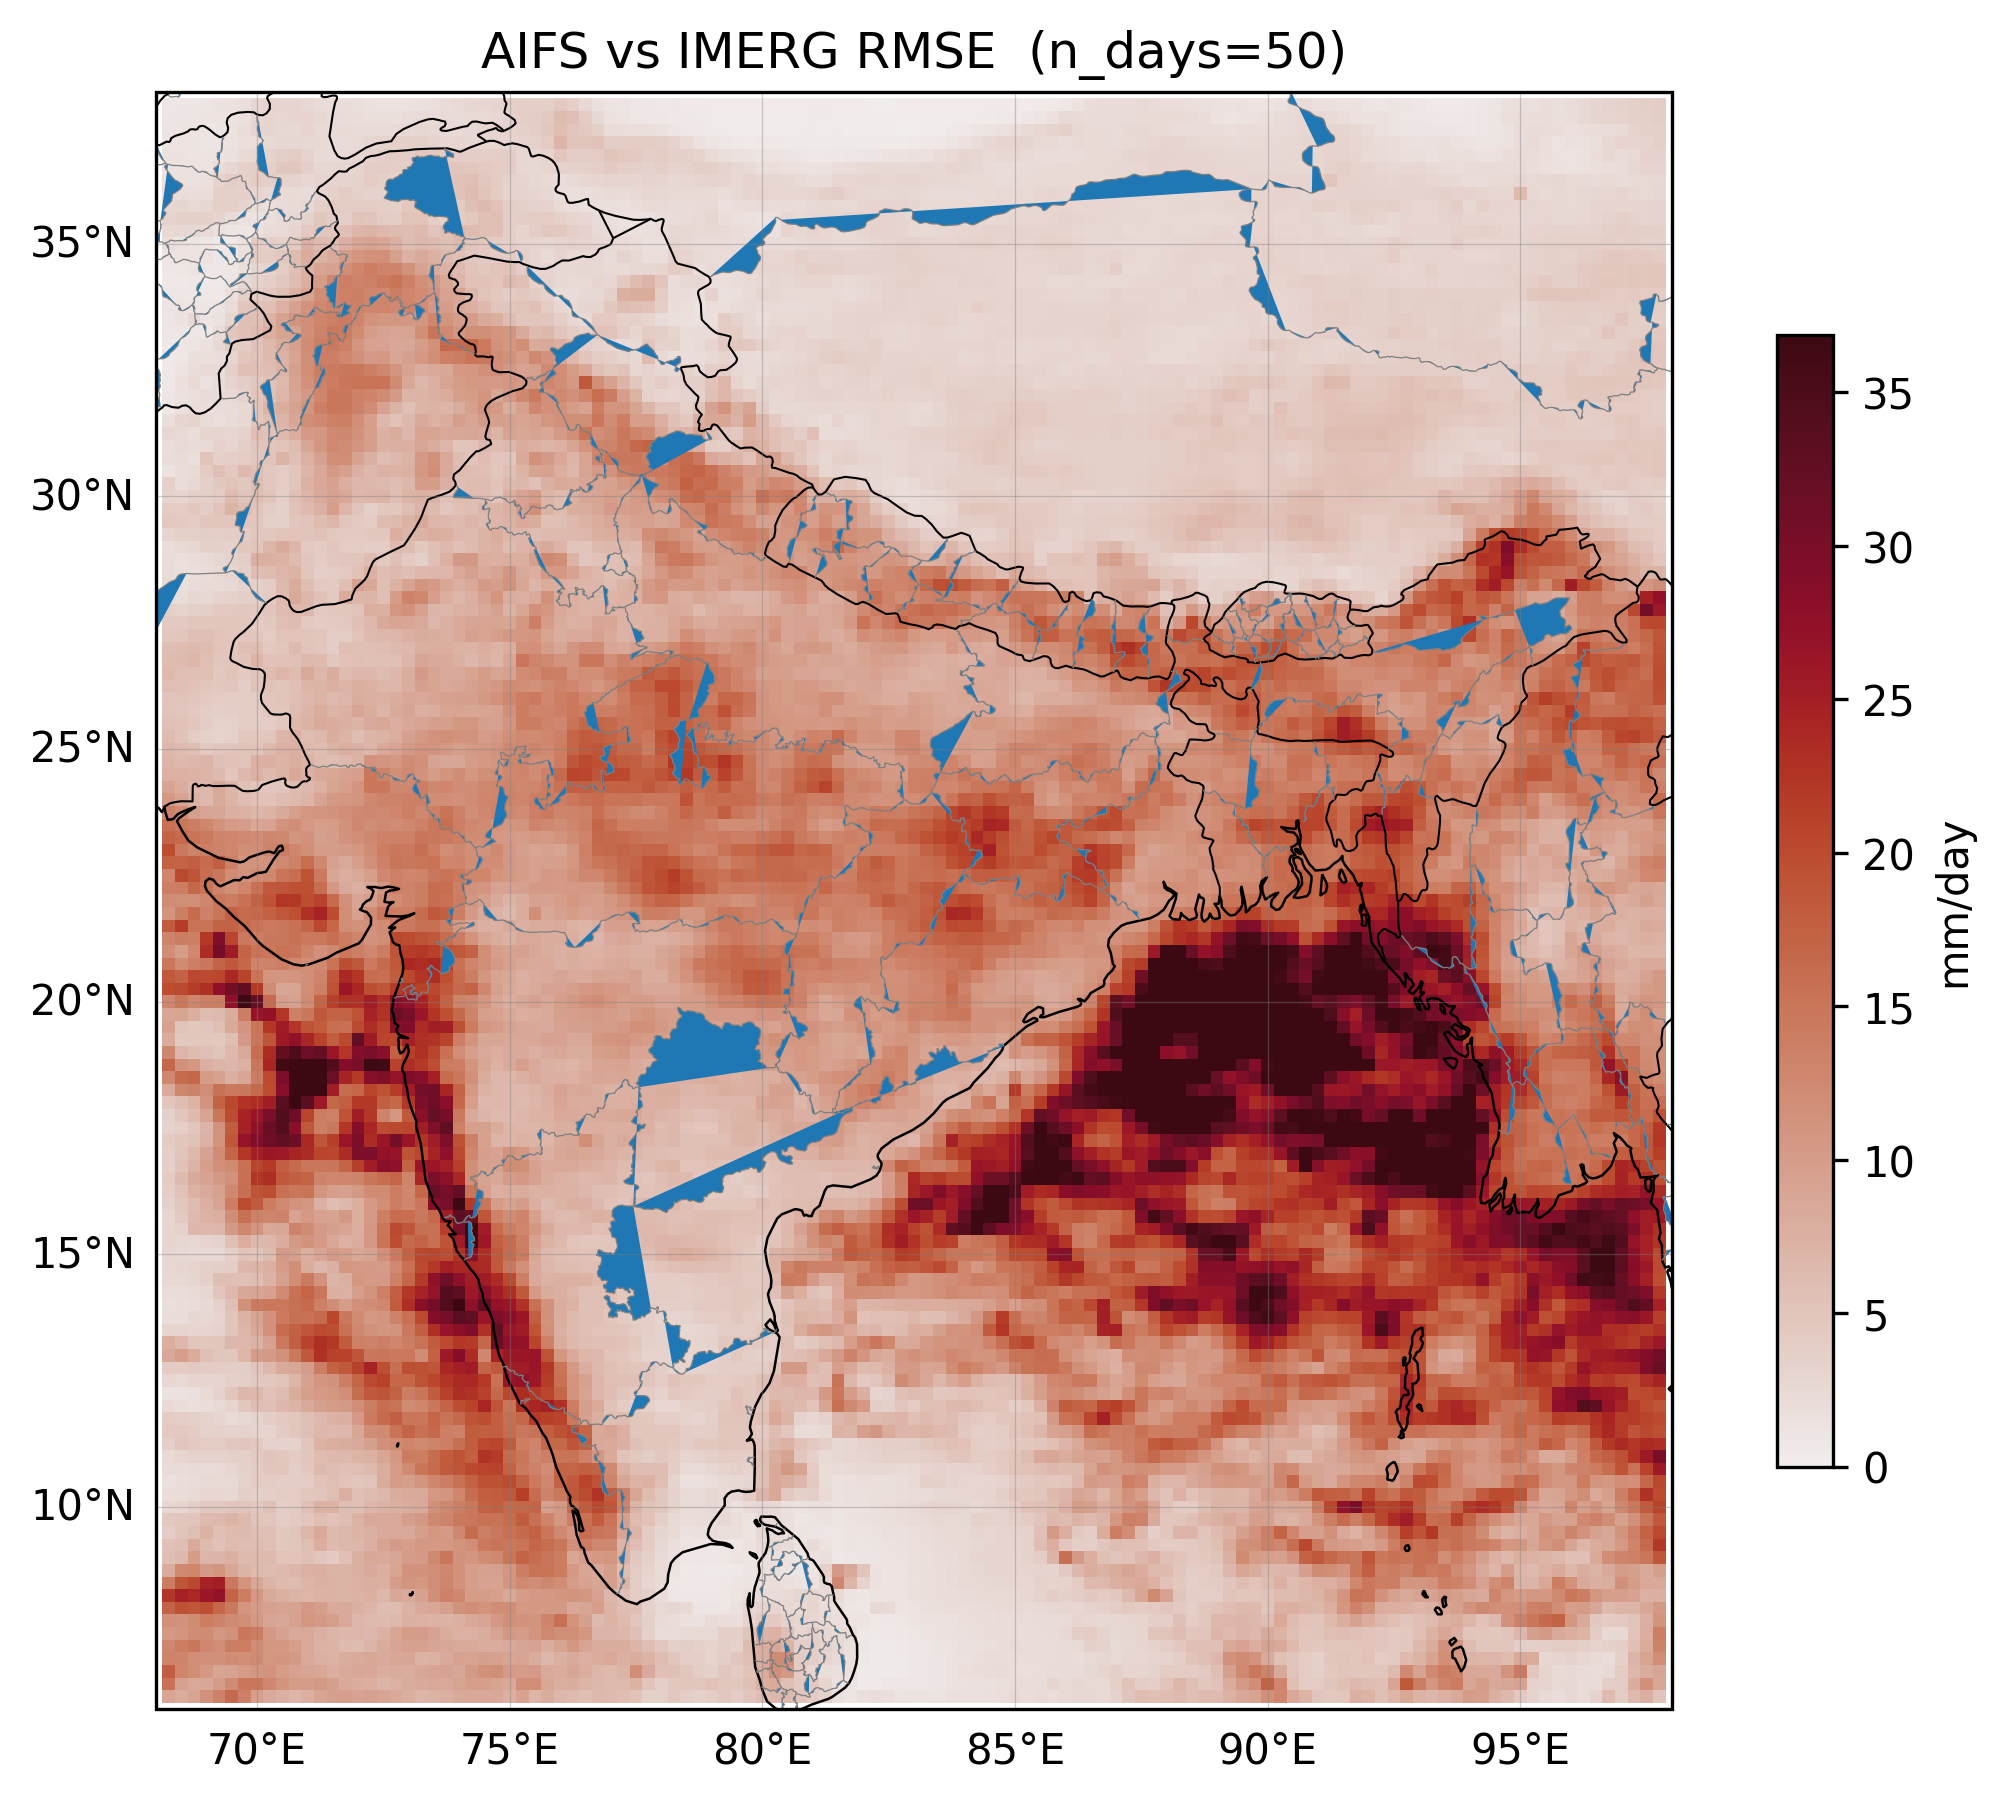

In [8]:
aifs_rmse = biaslib.rmse_map(ds)
out = plots.plot_rmse_map(
    aifs_rmse,
    FIG_DIR / "02_rmse_aifs.png",
    title=f"AIFS vs IMERG RMSE  (n_days={n_days})",
)
Image(filename=str(out))
        

### 6c. Bias by named region

Six rectangular regions of meteorological interest. See `config.REGIONS` for
exact bounding boxes.
        

region                         bias      RMSE           n
----------------------------------------------------------
western_ghats_windward        -0.99     19.04      23,850
western_ghats_leeward          0.22     11.54      29,150
gangetic_plain                 1.54     11.82      61,250
northeast                      2.44     14.27      53,650
himalayan_foothills            2.00      8.08      68,850
peninsular_interior            0.35      9.65      59,450


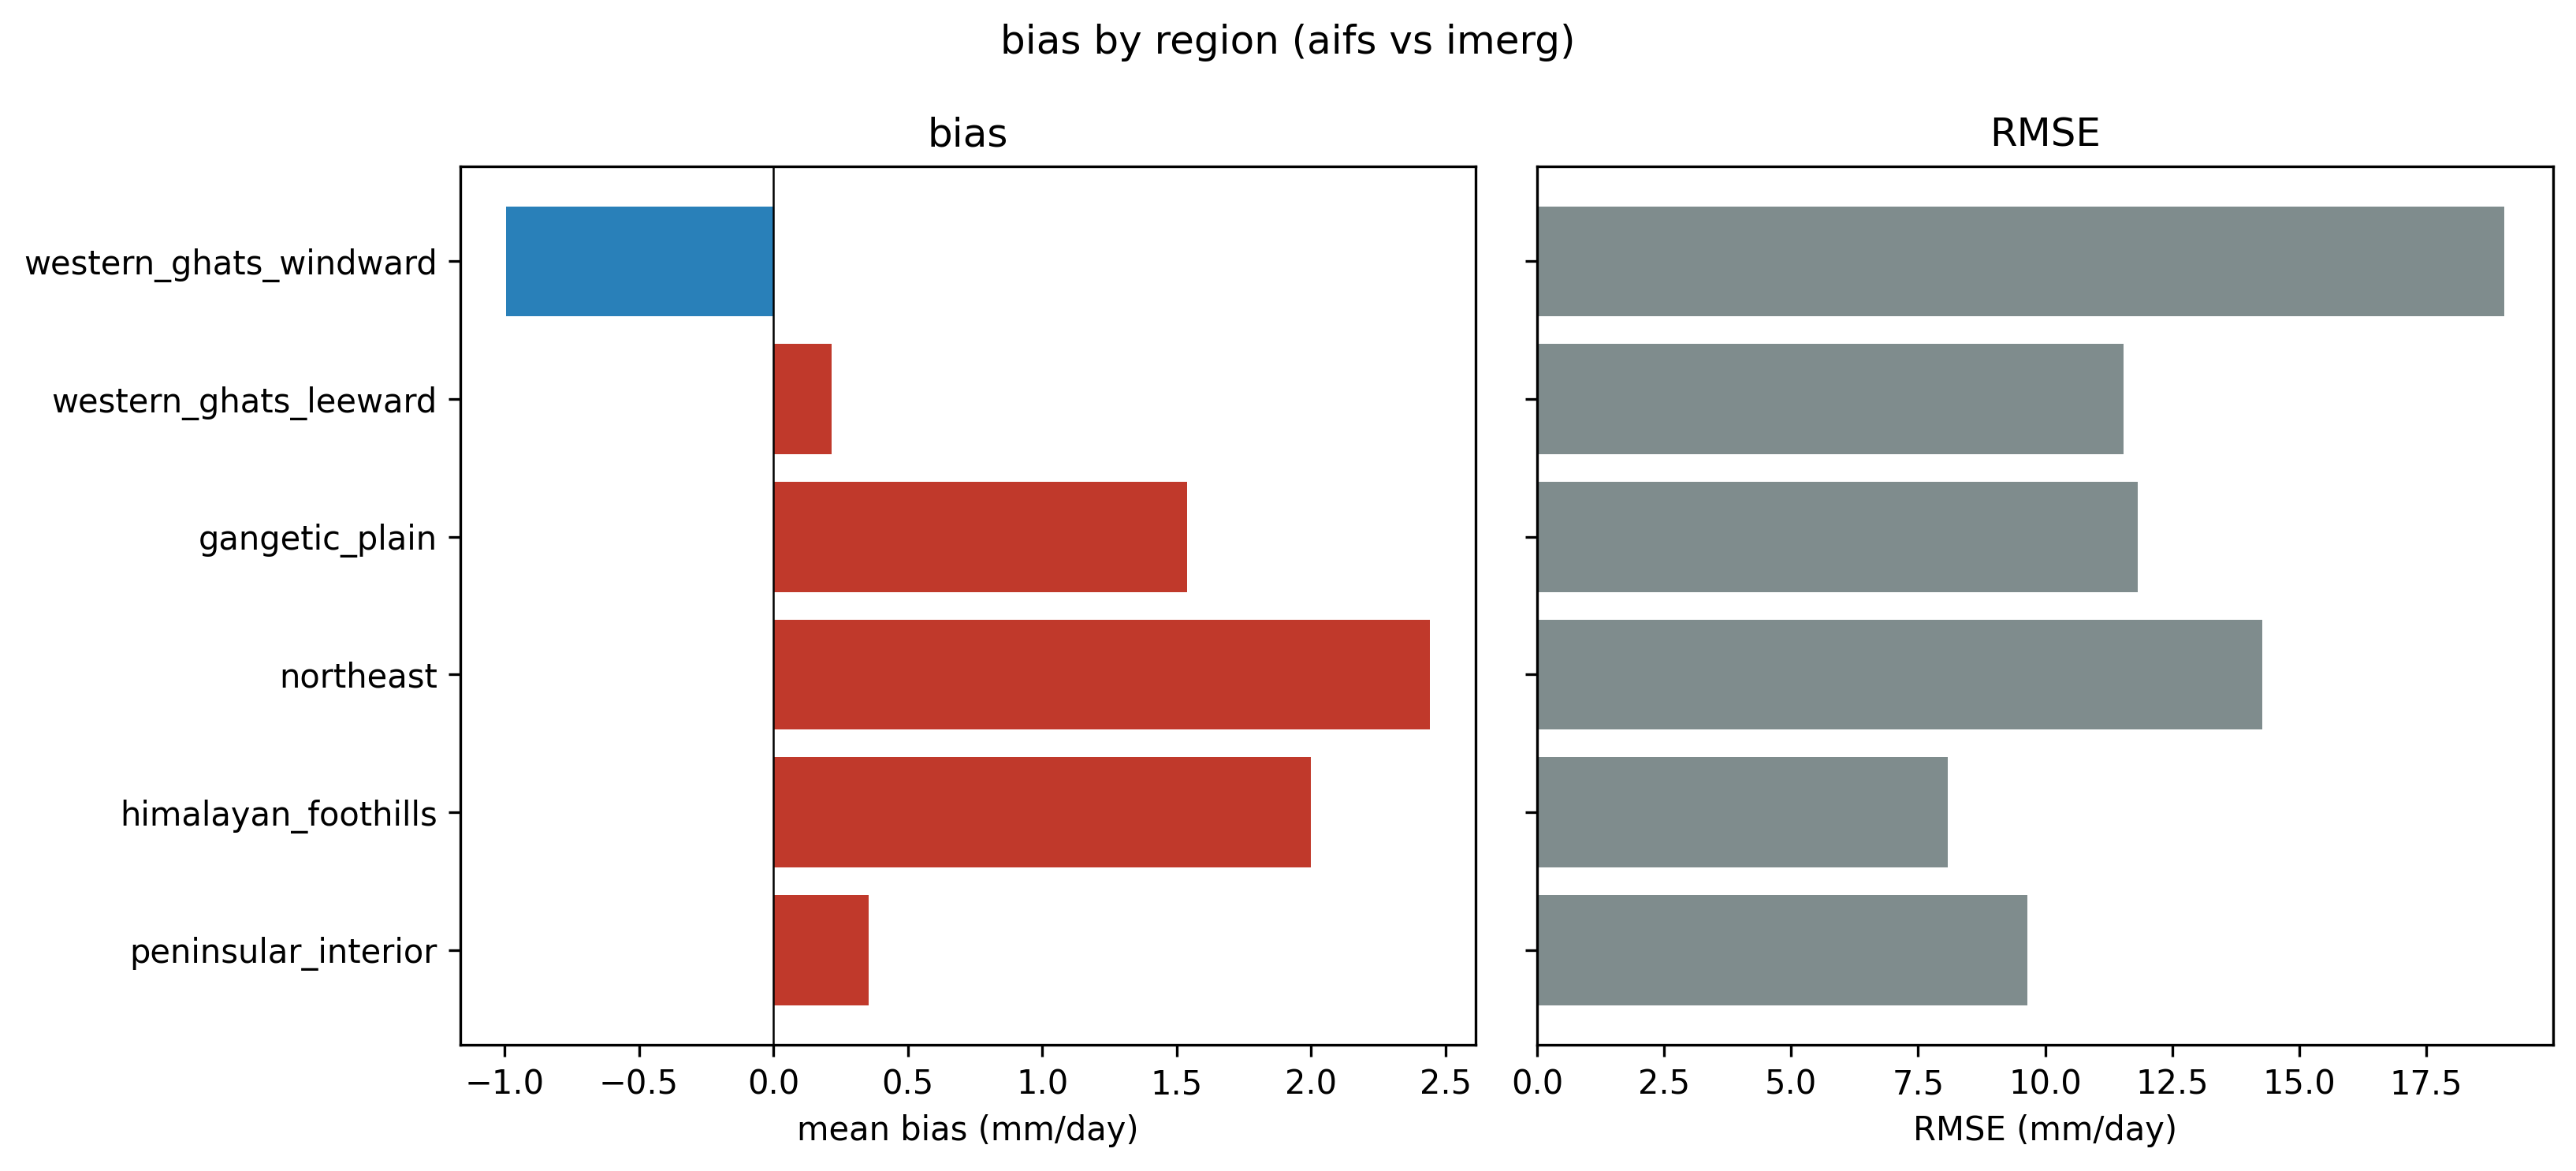

In [9]:
region_stats = biaslib.bias_by_region(ds)

print(f"{'region':25s}  {'bias':>8s}  {'RMSE':>8s}  {'n':>10s}")
print("-" * 58)
for r, b, e, c in zip(
    region_stats.region.values,
    region_stats.bias.values,
    region_stats.rmse.values,
    region_stats["count"].values,
):
    print(f"{r:25s}  {b:8.2f}  {e:8.2f}  {c:10,d}")

out = plots.plot_bias_by_region(
    region_stats,
    FIG_DIR / "04_bias_by_region_aifs.png",
)
Image(filename=str(out))
        

## 7. Limitations

- **Sample size.** Reflects whatever fraction of the 122-day season has been
  populated by the pod batch. Magnitudes (especially in the heavy-rain bins)
  will tighten as more days arrive; the structural findings will not change.
- **No land mask.** Ocean cells are included. IMERG quality over ocean
  differs from land; map figures should be re-rendered with a land mask
  before publication.
- **BSISO phase stratification is deferred.** The plan was to also stratify
  by active/break monsoon phase via Kikuchi's BSISO index. Kikuchi's
  real-time file has been dormant since 2022; APCC's product is gated.
  Self-computing the index from NOAA OLR + IPRC EEOF vectors is tractable
  but deferred. None of the three findings above depend on it.
- **2025 only.** Single-season evaluation. Structural findings are consistent
  with multi-year literature on similar models; we don't expect another year
  to invert them, but the precise magnitudes are 2025-specific.
- **AIFS only.** No GraphCast/Pangu comparison. GraphCast lacks native
  precipitation; Pangu is on a deprecation track. A probabilistic ensemble
  (AIFS-ENS, GenCast) comparison is the natural Proto 2 extension.
        

## 8. Conclusion

The precondition for a corrective-head follow-on is met. AIFS's bias over the
Indian monsoon is structured, geographically coherent, and physically
interpretable across three independent stratifications. None of the
structures are diffuse noise.

For Proto 2 — *does the ranking of probabilistic models depend on the
atmospheric regime?* — see `WRITEUP.md` for the BSISO-vs-MJO-RMM data-source
discussion and a revised compute estimate (~50–100 hr H100, $150–300).
        